2026-02-19 17:35:09.904771: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771522510.302446      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771522510.404805      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1771522560.519661      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


I0000 00:00:1771522592.318152      99 service.cc:148] XLA service 0x7ea3300016a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771522592.319758      99 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771522596.068853      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/79 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.5078 - loss: 6.3891  

I0000 00:00:1771522610.497681      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


79/79 ━━━━━━━━━━━━━━━━━━━━ 120s 993ms/step - accuracy: 0.5832 - loss: 9.7620 - val_accuracy: 0.6969 - val_loss: 2.2980
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 384ms/step - accuracy: 0.7805 - loss: 1.1697 - val_accuracy: 0.7985 - val_loss: 0.8488
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.8517 - loss: 0.4679 - val_accuracy: 0.8540 - val_loss: 0.3093
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.8928 - loss: 0.2677 - val_accuracy: 0.8632 - val_loss: 0.3967
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 376ms/step - accuracy: 0.8918 - loss: 0.2622 - val_accuracy: 0.9076 - val_loss: 0.2114
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.9091 - loss: 0.2315 - val_accuracy: 0.8799 - val_loss: 0.3013
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 373ms/step - accuracy: 0.9105 - loss: 0.2345 - val_accuracy: 0.8484 - val_loss: 0.3605
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 30s 375ms/step - accuracy: 0.8915 - loss: 0.2833 - val_accurac

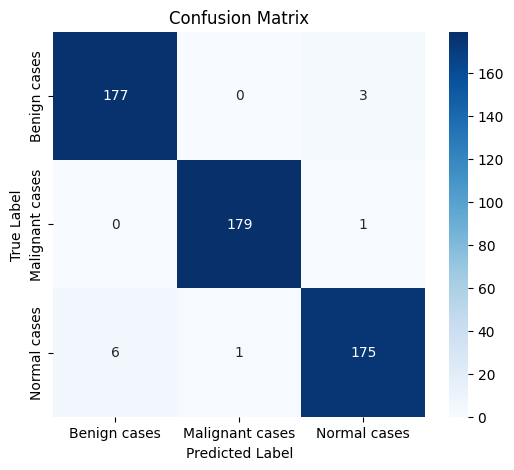

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.densenet import DenseNet169, preprocess_input
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ========================
# 1. Load Dataset with CLAHE
# ========================
data_dir = '/kaggle/input/iq-othnccd-lung-cancer-dataset-augmented/Augmented IQ-OTHNCCD lung cancer dataset'
categories = ['Benign cases', 'Malignant cases', 'Normal cases']
num_classes = len(categories)

def load_images(data_dir, img_size=224):
    X, y = [], []
    for cls in categories:
        cls_folder = os.path.join(data_dir, cls)
        for img_file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # --- Convert to grayscale and apply CLAHE ---
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

            # --- Back to 3 channels (DenseNet expects 3-channel input) ---
            img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

            # Resize + preprocess for DenseNet169
            img = cv2.resize(img, (img_size, img_size))
            img = preprocess_input(img)

            X.append(img)
            y.append(cls)

    X = np.array(X, dtype="float32")
    y = LabelEncoder().fit_transform(y)
    y = to_categorical(y, num_classes=num_classes)
    return X, y

X, y = load_images(data_dir)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ========================
# 2. Class Weights
# ========================
y_integers = np.argmax(y_train, axis=1)
class_weights = compute_class_weight('balanced', classes=np.unique(y_integers), y=y_integers)
class_weights = dict(enumerate(class_weights))

# ========================
# 3. Data Augmentation
# ========================
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2]
)
datagen.fit(X_train)

# ========================
# 4. Build DenseNet169 Model
# ========================
base_model = DenseNet169(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Phase 1: Freeze

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ========================
# 5. Train Phase 1
# ========================
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=100,
    class_weight=class_weights,
)

# ========================
# 7. Evaluation
# ========================
val_loss, val_acc = model.evaluate(X_val, y_val)
train_loss, train_acc = model.evaluate(X_train, y_train)
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# ========================
# 8. Classification Report & Confusion Matrix
# ========================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=categories))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories,
            yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


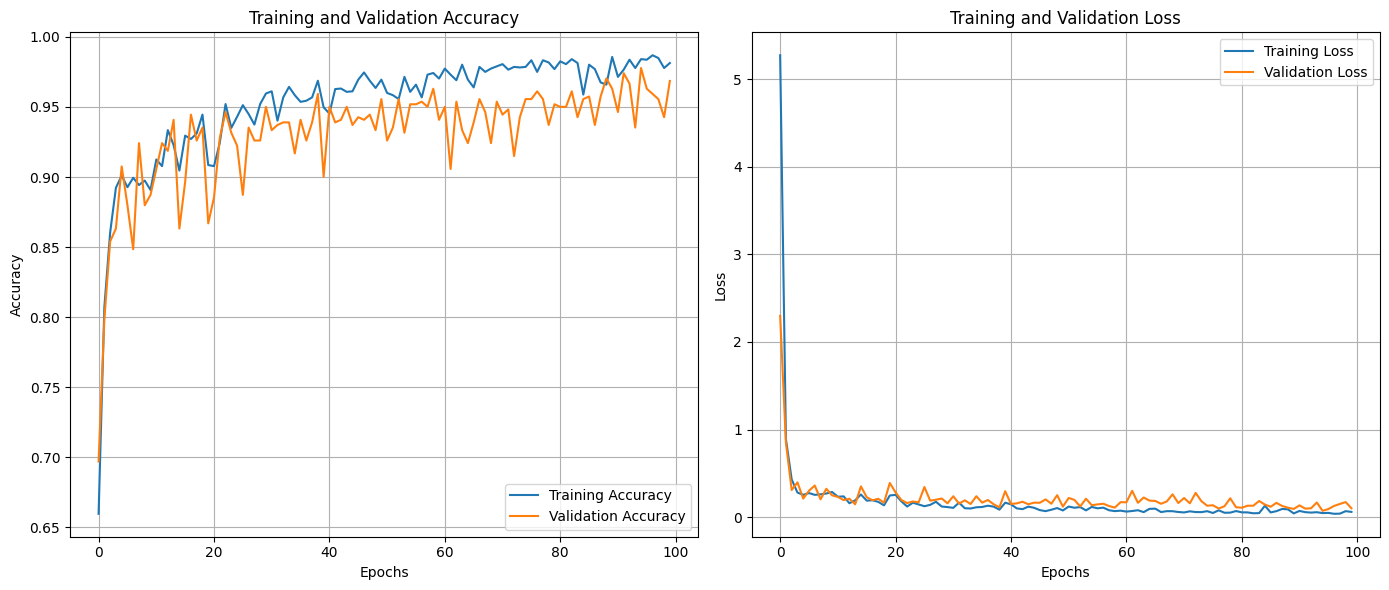

In [2]:
# ========================
# 9. Plot Training History (Accuracy & Loss)
# ========================
import matplotlib.pyplot as plt

# Extract history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

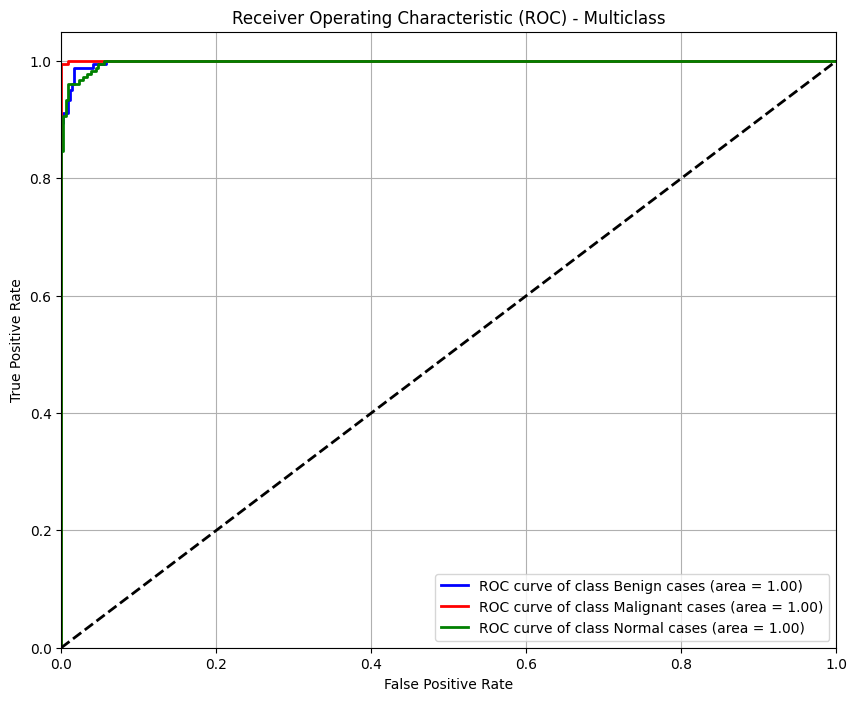

In [3]:
# ========================
# 10. ROC Curve & AUC
# ========================
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Calculate ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green']) # Colors for your 3 classes

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {categories[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
y_labels = np.argmax(y, axis=1)
def build_densenet169(num_classes):
    base_model = DenseNet169(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [5]:
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold = 1
fold_accuracies = []

for train_idx, val_idx in skf.split(X, y_labels):
    print(f"\n====================")
    print(f" Training Fold {fold}")
    print(f"====================")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ---- Class weights ----
    y_train_int = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_int),
        y=y_train_int
    )
    class_weights = dict(enumerate(class_weights))

    # ---- Data Augmentation ----
    datagen = ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        shear_range=0.1,
        brightness_range=[0.8, 1.2]
    )
    datagen.fit(X_train)

    # ---- Build Model ----
    model = build_densenet169(num_classes)

    # ---- Train ----
    model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_val, y_val),
        epochs=50,
        class_weight=class_weights,
        verbose=1
    )

    # ---- Evaluate ----
    y_val_pred = model.predict(X_val)
    y_val_pred_cls = np.argmax(y_val_pred, axis=1)
    y_val_true = np.argmax(y_val, axis=1)

    acc = accuracy_score(y_val_true, y_val_pred_cls)
    fold_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc*100:.2f}%")
    fold += 1



 Training Fold 1


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 112s 859ms/step - accuracy: 0.5190 - loss: 21.9964 - val_accuracy: 0.7715 - val_loss: 0.7350
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.7907 - loss: 0.5536 - val_accuracy: 0.7216 - val_loss: 0.9837
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 370ms/step - accuracy: 0.7813 - loss: 0.5369 - val_accuracy: 0.8726 - val_loss: 0.3142
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8877 - loss: 0.2772 - val_accuracy: 0.8975 - val_loss: 0.2467
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8760 - loss: 0.3152 - val_accuracy: 0.9030 - val_loss: 0.2733
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8710 - loss: 0.3095 - val_accuracy: 0.9127 - val_loss: 0.2317
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - accuracy: 0.8906 - loss: 0.2711 - val_accuracy: 0.9086 - val_loss: 0.2055
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.9018 - loss: 0.2333 - val_ac

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 102s 738ms/step - accuracy: 0.5438 - loss: 15.6977 - val_accuracy: 0.7479 - val_loss: 1.1093
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.7837 - loss: 0.9767 - val_accuracy: 0.8573 - val_loss: 0.4532
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 369ms/step - accuracy: 0.8424 - loss: 0.5113 - val_accuracy: 0.8629 - val_loss: 0.4266
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.8441 - loss: 0.4586 - val_accuracy: 0.8740 - val_loss: 0.3237
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8882 - loss: 0.3029 - val_accuracy: 0.8753 - val_loss: 0.2747
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - accuracy: 0.8918 - loss: 0.2478 - val_accuracy: 0.9058 - val_loss: 0.2170
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.9224 - loss: 0.2050 - val_accuracy: 0.7632 - val_loss: 0.7533
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 371ms/step - accuracy: 0.8881 - loss: 0.3161 - val_ac

...

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 103s 750ms/step - accuracy: 0.5170 - loss: 16.2207 - val_accuracy: 0.8380 - val_loss: 0.4625
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.8173 - loss: 0.5075 - val_accuracy: 0.8670 - val_loss: 0.2857
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8676 - loss: 0.3485 - val_accuracy: 0.5845 - val_loss: 2.1702
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.7924 - loss: 0.8157 - val_accuracy: 0.8698 - val_loss: 0.3550
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8831 - loss: 0.2981 - val_accuracy: 0.9127 - val_loss: 0.2112
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.8856 - loss: 0.3320 - val_accuracy: 0.8657 - val_loss: 0.2731
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 375ms/step - accuracy: 0.9153 - loss: 0.2436 - val_accuracy: 0.8975 - val_loss: 0.2615
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8803 - loss: 0.3129 - val_ac

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 104s 750ms/step - accuracy: 0.5295 - loss: 15.2496 - val_accuracy: 0.7659 - val_loss: 1.2762
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 374ms/step - accuracy: 0.8009 - loss: 0.8146 - val_accuracy: 0.8075 - val_loss: 0.8665
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8277 - loss: 0.6375 - val_accuracy: 0.8878 - val_loss: 0.2553
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 380ms/step - accuracy: 0.8216 - loss: 0.5609 - val_accuracy: 0.8740 - val_loss: 0.3420
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 378ms/step - accuracy: 0.8951 - loss: 0.2436 - val_accuracy: 0.8504 - val_loss: 0.4633
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8978 - loss: 0.2471 - val_accuracy: 0.9169 - val_loss: 0.2058
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8962 - loss: 0.2534 - val_accuracy: 0.8629 - val_loss: 0.3710
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8791 - loss: 0.3047 - val_ac

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 116s 889ms/step - accuracy: 0.5431 - loss: 13.9680 - val_accuracy: 0.7920 - val_loss: 1.2897
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 35s 379ms/step - accuracy: 0.7863 - loss: 1.3073 - val_accuracy: 0.8391 - val_loss: 0.6203
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.7984 - loss: 0.9482 - val_accuracy: 0.8835 - val_loss: 0.3065
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8891 - loss: 0.2715 - val_accuracy: 0.8877 - val_loss: 0.2547
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 376ms/step - accuracy: 0.8914 - loss: 0.2716 - val_accuracy: 0.8433 - val_loss: 0.4085
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.8984 - loss: 0.2312 - val_accuracy: 0.9015 - val_loss: 0.2229
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 378ms/step - accuracy: 0.9002 - loss: 0.2664 - val_accuracy: 0.8835 - val_loss: 0.2731
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 34s 373ms/step - accuracy: 0.8942 - loss: 0.2544 - val_ac

In [6]:
print("\n====================")
print(" Cross Validation Result ")
print("====================")
print(f"Mean Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
print(f"Std Deviation: {np.std(fold_accuracies)*100:.2f}%")



 Cross Validation Result 
Mean Accuracy: 95.12%
Std Deviation: 1.66%


In [7]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # 1. Access the nested base model (DenseNet169)
    #    In your code, model.layers[0] is the DenseNet169
    base_model = model.layers[0]
    
    # 2. Create a sub-model that outputs:
    #    - The last convolutional layer (for the heatmap)
    #    - The final output of the base model (to pass to the rest of your layers)
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 3. Compute gradients
    with tf.GradientTape() as tape:
        # Get the conv output and the features from the base model
        last_conv_layer_output, base_model_features = grad_model(img_array)
        
        # MANUALLY pass the base_model_features through the rest of your Sequential layers
        # Your model structure: [Base, Flatten, Dense, Dense, Dense]
        # So we start from layer index 1
        x = base_model_features
        for layer in model.layers[1:]:
            x = layer(x)
        
        # Now 'x' contains the final predictions
        preds = x
        
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 4. Calculate gradient of the predicted class with respect to the conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 5. Global Average Pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 6. Multiply each channel by its importance
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 7. Normalize heatmap
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
True: Malignant cases | Pred: Malignant cases


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_3005']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_38/88227297.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  jet = cm.get_cmap("jet")


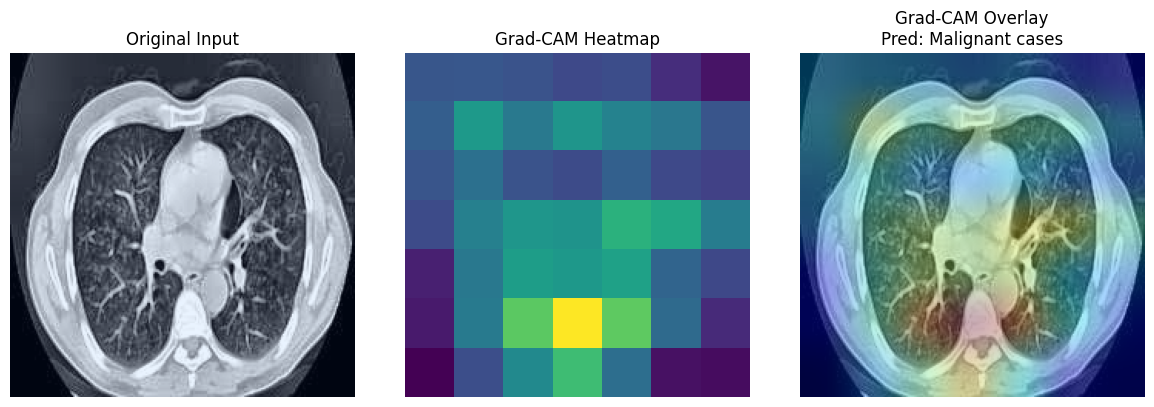

In [8]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# --- Re-paste the 'display_gradcam' function if you haven't defined it yet ---
def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    # Normalize original image for display
    disp_img = img.copy()
    disp_img = (disp_img - np.min(disp_img)) / (np.max(disp_img) - np.min(disp_img))
    disp_img = np.uint8(255 * disp_img)

    superimposed_img = jet_heatmap * alpha + disp_img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

# --- EXECUTION ---

# 1. Define the layer name for DenseNet169
last_conv_layer_name = "relu"

# 2. Pick an image
img_index = 0  # Change this to see different images
img_tensor = X_test[img_index]
img_array = np.expand_dims(img_tensor, axis=0)

# 3. Get Prediction info for title
preds = model.predict(img_array)
pred_idx = np.argmax(preds[0])
true_idx = np.argmax(y_test[img_index])
print(f"True: {categories[true_idx]} | Pred: {categories[pred_idx]}")

# 4. Generate Heatmap (Using the FIXED function)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# 5. Display
superimposed_img = display_gradcam(img_tensor, heatmap)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow((img_tensor - img_tensor.min()) / (img_tensor.max() - img_tensor.min()))
plt.title("Original Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM Overlay\nPred: {categories[pred_idx]}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
model.save("/kaggle/working/Dense169.h5")

In [12]:
import os

print(os.listdir("/kaggle/working/"))

['.virtual_documents', 'Dense169.h5']


In [13]:
from IPython.display import FileLink
FileLink('/kaggle/working/Dense169.h5')


/kaggle/working/Dense169.h5